<a href="https://colab.research.google.com/github/Epot12/DLA/blob/master/jupyter/Model_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep learning for Head Acceleration reconstruction PYTORCH

###Caricamento e normalizzazione dei dati .mat

In [1]:
import scipy.io
import numpy as np
import torch
import json
import os
import matplotlib.pyplot as plt

#Funzione che carica i dati dal file matlab
def load_mat_files(fname, cell, n_samples, n_features, timespan, normalize = False, norm = 0):
    data = np.zeros((n_samples, n_features, timespan), dtype=float)
    mat = scipy.io.loadmat(fname, matlab_compatible=True)
    ndarray = mat.get(cell)

    for i in range(n_samples):
        temp = ndarray[i]
        sim = np.array([np.array(val) for val in temp])
        if normalize:
          data[i] = sim[0]/norm #operazione element-wise, applicata a tutti gli elementi della matrice in modo indipendente
        else:
          data[i] = sim[0]
    return data #restituisce dati in formato (n_samples, n_features, timespan)

def convert_mat_files_mean_std (fname, cell, n_samples, n_features, timespan, save_stats_path):
    # Calcolo media e deviazione standard per ogni feature
    data = load_mat_files(fname, cell, n_samples, n_features, timespan)
    feature_means = data.mean(axis=(0, 2))
    feature_stds = data.std(axis=(0, 2))
    feature_stds[feature_stds == 0] = 1e-8  # Evita divisione per zero

    # Normalizzazione
    for f in range(n_features):
        data[:, f, :] = (data[:, f, :] - feature_means[f]) / feature_stds[f]

    # Salvataggio statistiche di normalizzazione
    if save_stats_path:
        stats = {
            "feature_means": feature_means.tolist(),
            "feature_stds": feature_stds.tolist()
        }
        os.makedirs(os.path.dirname(save_stats_path), exist_ok=True)
        with open(save_stats_path, 'w') as f:
            json.dump(stats, f, indent=4)

    return data #restituisce dati in formato (n_samples, n_features, timespan)






def convert_mat_files_input_with_stats(fname, cell, n_samples, n_features, timespan, stats_path):
    """
    Carica dati da un file .mat e li normalizza usando mean e std pre-salvati in un file JSON.
    Restituisce dati nella forma (samples, timespan, features) per PyTorch.
    """
    data = load_mat_files(fname, cell, n_samples, n_features, timespan)
    # Carica le statistiche dal file JSON
    with open(stats_path, 'r') as f:
        stats = json.load(f)

    feature_means = np.array(stats["feature_means"])
    feature_stds = np.array(stats["feature_stds"])
    feature_stds[feature_stds == 0] = 1e-8  # per evitare divisioni per zero

    # Normalizza i dati con mean e std pre-salvati
    for f in range(n_features):
        data[:, f, :] = (data[:, f, :] - feature_means[f]) / feature_stds[f]

    return data #restituisce dati in formato (n_samples, n_features, timespan)


import torch

def inverse_standardization(y_pred_norm, means, stds):
    """
    Inverte la standardizzazione (z-score) dei dati normalizzati.

    Args:
        y_pred_norm (torch.Tensor): Tensore normalizzato di forma (samples, n_features, times)
        means (Union[torch.Tensor, np.ndarray, list]): Medie per ciascuna feature (forma: n_features)
        stds (Union[torch.Tensor, np.ndarray, list]): Deviazioni standard per ciascuna feature (forma: n_features)

    Returns:
        torch.Tensor: Tensore non normalizzato (stessa forma di y_pred_norm)
    """
    # Se means/stds non sono torch.Tensor, convertirli
    if not isinstance(means, torch.Tensor):
        means = torch.tensor(means, dtype=y_pred_norm.dtype, device=y_pred_norm.device)
    if not isinstance(stds, torch.Tensor):
        stds = torch.tensor(stds, dtype=y_pred_norm.dtype, device=y_pred_norm.device)

    # Assicurati che abbiano la forma corretta per il broadcasting: (n_features, 1)
    means = means.view(-1, 1)
    stds = stds.view(-1, 1)

    # Inverti la standardizzazione
    y_pred_orig = y_pred_norm * stds + means
    return y_pred_orig


###Exploratory Data Analysis

In [2]:
def plot_feature_stats(data, title_prefix="Input"):
    """
    Calcola media e std per ciascuna feature, aggregando su samples e timestep.
    data: np.array di shape (n_samples, n_features, timespan)
    """
    # Calcola media e std su samples e timestep → per ogni feature
    means = data.mean(axis=(0, 2))  # shape: (n_features,)
    stds = data.std(axis=(0, 2))    # shape: (n_features,)

    plt.figure(figsize=(10, 4))
    plt.bar(range(len(means)), means, yerr=stds)
    plt.title(f'{title_prefix} Feature Mean ± Std')
    plt.xlabel('Feature Index')
    plt.ylabel('Value')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def plot_sample_series(data, index=0, title_prefix="Input"):
    """
    Funzione che sceglie alcuni esempi e visualizza le serie temporali.
    data: shape (samples, features, timespan)
    """
    timespan = data.shape[2]
    features = data.shape[1]
    fig, axs = plt.subplots(features, 1, figsize=(10, features * 2))
    for f in range(features):
        axs[f].plot(range(timespan), data[index, f, :])
        axs[f].set_title(f'{title_prefix} Feature {f} - Sample {index}')
        axs[f].grid(True)
    plt.tight_layout()
    plt.show()



In [3]:
#carico i dati
train_expl = load_mat_files('Data_input_training_lin_comp.mat', 'I_train', 3000, 5, 125) #estrazione dei dati dal file matlab
val_expl = load_mat_files('Data_input_validation_lin_comp.mat', 'I_validation', 600, 5, 125)
train_expl_labels = load_mat_files('Data_output_training_lin_comp.mat', 'O_train', 3000, 3, 125)
val_expl_labels = load_mat_files('Data_output_validation_lin_comp.mat', 'O_validation', 600, 3, 125)
#plotto i grafici
plot_feature_stats(train_expl)
plot_feature_stats(val_expl)

OSError: could not read bytes

In [ ]:
#visualizzo le serie temporali
plot_sample_series(train_expl)
plot_sample_series(val_expl)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, fft
import pandas as pd
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

def visualize_time_series(data, n_samples=3, random_seed=42):
    """
    Visualizza serie temporali per un sottoinsieme di campioni

    Args:
        data: np.array di forma (n_samples, n_features, timespan)
        n_samples: Numero di campioni da visualizzare
        random_seed: Seed per la selezione casuale
    """
    np.random.seed(random_seed)
    n_features = data.shape[1]
    timespan = data.shape[2]

    # Seleziona campioni casuali
    sample_indices = np.random.choice(data.shape[0], n_samples, replace=False)

    # Crea un grafico per ogni feature
    for f in range(n_features):
        plt.figure(figsize=(12, 6))
        for i, idx in enumerate(sample_indices):
            plt.plot(range(timespan), data[idx, f, :], label=f'Sample {idx}', alpha=0.8)

        plt.title(f'Feature {f}: Serie Temporale per {n_samples} Campioni')
        plt.xlabel('Time Step')
        plt.ylabel('Valore')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

def visualize_feature_overlay(data, feature_idx=0, n_samples=50, random_seed=42):
    """
    Sovrappone più serie temporali per una specifica feature

    Args:
        data: np.array di forma (n_samples, n_features, timespan)
        feature_idx: Indice della feature da visualizzare
        n_samples: Numero di campioni da sovrapporre
        random_seed: Seed per la selezione casuale
    """
    np.random.seed(random_seed)
    timespan = data.shape[2]

    # Seleziona campioni casuali
    sample_indices = np.random.choice(data.shape[0], n_samples, replace=False)

    plt.figure(figsize=(12, 6))
    for idx in sample_indices:
        plt.plot(range(timespan), data[idx, feature_idx, :], alpha=0.2)

    # Calcola e disegna la media
    mean_series = data[:, feature_idx, :].mean(axis=0)
    plt.plot(range(timespan), mean_series, 'r-', linewidth=2, label='Media')

    plt.title(f'Feature {feature_idx}: Sovrapposizione di {n_samples} Serie Temporali')
    plt.xlabel('Time Step')
    plt.ylabel('Valore')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_distributions(data):
    """
    Visualizza istogrammi e box plot per ogni feature

    Args:
        data: np.array di forma (n_samples, n_features, timespan)
    """
    n_features = data.shape[1]

    # Riorganizza i dati per l'analisi
    flat_data = []
    for f in range(n_features):
        # Appiattisce i dati di ogni feature
        flat_feature = data[:, f, :].flatten()
        flat_data.append(flat_feature)

    # Istogrammi e density plot
    plt.figure(figsize=(15, 10))
    for f in range(n_features):
        plt.subplot(n_features, 2, 2*f+1)
        sns.histplot(flat_data[f], kde=True)
        plt.title(f'Feature {f}: Distribuzione dei Valori')
        plt.xlabel('Valore')
        plt.ylabel('Frequenza')

        plt.subplot(n_features, 2, 2*f+2)
        sns.boxplot(x=flat_data[f])
        plt.title(f'Feature {f}: Box Plot')
        plt.xlabel('Valore')

    plt.tight_layout()
    plt.show()

def plot_correlation_matrix(data):
    """
    Visualizza la matrice di correlazione tra features

    Args:
        data: np.array di forma (n_samples, n_features, timespan)
    """
    n_features = data.shape[1]

    # Calcola la correlazione media nel tempo
    corr_matrix = np.zeros((n_features, n_features))

    # Media dei valori per ogni feature e campione
    feature_means = data.mean(axis=2)  # shape: (n_samples, n_features)

    # Calcola la correlazione delle medie
    corr_matrix = np.corrcoef(feature_means.T)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=range(n_features), yticklabels=range(n_features))
    plt.title('Matrice di Correlazione tra Features')
    plt.tight_layout()
    plt.show()

    return corr_matrix

def scatter_feature_pairs(data, feat_idx1=0, feat_idx2=1, n_samples=500, random_seed=42):
    """
    Crea scatter plot tra coppie di features

    Args:
        data: np.array di forma (n_samples, n_features, timespan)
        feat_idx1, feat_idx2: Indici delle features da mettere in relazione
        n_samples: Numero di campioni da visualizzare
        random_seed: Seed per la selezione casuale
    """
    np.random.seed(random_seed)

    # Seleziona campioni casuali
    if data.shape[0] > n_samples:
        sample_indices = np.random.choice(data.shape[0], n_samples, replace=False)
        data_subset = data[sample_indices]
    else:
        data_subset = data

    # Media dei valori per ogni feature e campione
    feature_means = data_subset.mean(axis=2)  # shape: (n_samples, n_features)

    plt.figure(figsize=(10, 8))
    plt.scatter(feature_means[:, feat_idx1], feature_means[:, feat_idx2], alpha=0.6)
    plt.title(f'Scatter Plot: Feature {feat_idx1} vs Feature {feat_idx2}')
    plt.xlabel(f'Feature {feat_idx1} (media)')
    plt.ylabel(f'Feature {feat_idx2} (media)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_frequency_analysis(data, sample_idx=0, feature_idx=0):
    """
    Analisi in frequenza per una specifica serie temporale

    Args:
        data: np.array di forma (n_samples, n_features, timespan)
        sample_idx: Indice del campione da analizzare
        feature_idx: Indice della feature da analizzare
    """
    series = data[sample_idx, feature_idx, :]
    n = len(series)

    # FFT
    yf = fft.fft(series)
    xf = fft.fftfreq(n, 1)[:n//2]

    plt.figure(figsize=(12, 10))

    # Serie temporale originale
    plt.subplot(2, 1, 1)
    plt.plot(range(n), series)
    plt.title(f'Serie Temporale: Sample {sample_idx}, Feature {feature_idx}')
    plt.xlabel('Time Step')
    plt.ylabel('Valore')
    plt.grid(True, linestyle='--', alpha=0.5)

    # Spettro di frequenza
    plt.subplot(2, 1, 2)
    plt.plot(xf, 2.0/n * np.abs(yf[0:n//2]))
    plt.title('Spettro di Frequenza')
    plt.xlabel('Frequenza')
    plt.ylabel('Ampiezza')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Spettrogramma
    plt.figure(figsize=(10, 6))
    f, t, Sxx = signal.spectrogram(series)
    plt.pcolormesh(t, f, Sxx, shading='gouraud')
    plt.title(f'Spettrogramma: Sample {sample_idx}, Feature {feature_idx}')
    plt.ylabel('Frequenza')
    plt.xlabel('Time Step')
    plt.colorbar(label='Intensità')
    plt.tight_layout()
    plt.show()



In [ ]:
def plot_pca_analysis(data):
    """
    Analisi delle componenti principali (PCA) del dataset

    Args:
        data: np.array di forma (n_samples, n_features, timespan)
    """
    # Riorganizza i dati: media di ogni feature per ogni campione
    n_samples = data.shape[0]
    n_features = data.shape[1]

    # Media dei valori per ogni feature e campione
    feature_means = data.mean(axis=2)  # shape: (n_samples, n_features)

    # Applica PCA
    pca = PCA(n_components=min(3, n_features))
    pca_result = pca.fit_transform(feature_means)

    # Visualizza risultati PCA
    plt.figure(figsize=(12, 10))

    # Varianza spiegata
    plt.subplot(2, 1, 1)
    plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
    plt.ylabel('Varianza Spiegata')
    plt.xlabel('Componente Principale')
    plt.title('Varianza Spiegata da Ogni Componente Principale')
    plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
    plt.grid(True, linestyle='--', alpha=0.5)

    # Scatter plot delle prime due componenti
    plt.subplot(2, 1, 2)
    plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
    plt.xlabel('Prima Componente Principale')
    plt.ylabel('Seconda Componente Principale')
    plt.title('PCA: Prime Due Componenti')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Se abbiamo almeno 3 componenti, visualizzazione 3D
    if pca_result.shape[1] >= 3:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], alpha=0.5)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_zlabel('PC3')
        ax.set_title('PCA: Prime Tre Componenti')
        plt.tight_layout()
        plt.show()

    return pca, pca_result

def plot_feature_heatmap(data, sample_idx=0):
    """
    Visualizza una heatmap delle features nel tempo per un campione specifico

    Args:
        data: np.array di forma (n_samples, n_features, timespan)
        sample_idx: Indice del campione da analizzare
    """
    sample_data = data[sample_idx]  # shape: (n_features, timespan)

    plt.figure(figsize=(12, 6))
    sns.heatmap(sample_data, cmap='viridis')
    plt.title(f'Heatmap delle Features nel Tempo - Sample {sample_idx}')
    plt.xlabel('Time Step')
    plt.ylabel('Feature Index')
    plt.tight_layout()
    plt.show()

def plot_stats_over_time(data):
    """
    Visualizza statistiche delle features nel tempo

    Args:
        data: np.array di forma (n_samples, n_features, timespan)
    """
    n_features = data.shape[1]
    timespan = data.shape[2]

    # Calcola media e std per ogni feature e time step
    mean_over_time = data.mean(axis=0)  # shape: (n_features, timespan)
    std_over_time = data.std(axis=0)    # shape: (n_features, timespan)

    # Crea grafici
    fig, axs = plt.subplots(n_features, 1, figsize=(12, 3*n_features), sharex=True)

    for f in range(n_features):
        axs[f].plot(range(timespan), mean_over_time[f, :], 'b-', label='Media')
        axs[f].fill_between(
            range(timespan),
            mean_over_time[f, :] - std_over_time[f, :],
            mean_over_time[f, :] + std_over_time[f, :],
            alpha=0.3, color='b', label='±1 Std'
        )
        axs[f].set_title(f'Feature {f}: Media e Std nel Tempo')
        axs[f].set_ylabel('Valore')
        axs[f].grid(True, linestyle='--', alpha=0.5)
        axs[f].legend()

    axs[-1].set_xlabel('Time Step')
    plt.tight_layout()
    plt.show()


In [ ]:
def explore_dataset(data, title_prefix="Dataset"):
    """
    Esegue un'esplorazione completa del dataset

    Args:
        data: np.array di forma (n_samples, n_features, timespan)
        title_prefix: Prefisso per i titoli dei grafici
    """
    n_samples, n_features, timespan = data.shape

    print(f"===== Analisi del {title_prefix} =====")
    print(f"Dimensioni: {n_samples} campioni, {n_features} features, {timespan} time steps\n")

    # 1. Visualizzazioni base
    print("1. Statistiche globali per feature")
    feature_means = data.mean(axis=(0, 2))
    feature_stds = data.std(axis=(0, 2))

    for f in range(n_features):
        print(f"Feature {f}: Media = {feature_means[f]:.4f}, Std = {feature_stds[f]:.4f}")

    # 2. Analisi delle distribuzioni
    print("\n2. Visualizzazione distribuzioni e box plot...")
    plot_distributions(data)

    # 3. Serie temporali
    print("\n3. Visualizzazione serie temporali...")
    visualize_time_series(data, n_samples=3)

    # 4. Overlay di serie temporali
    print("\n4. Overlay di serie temporali...")
    for f in range(n_features):
        visualize_feature_overlay(data, feature_idx=f, n_samples=50)

    # 5. Correlazioni
    print("\n5. Matrice di correlazione tra features...")
    corr_matrix = plot_correlation_matrix(data)

    # 6. Scatter plots tra features più correlate
    print("\n6. Scatter plots tra features...")
    # Trova le coppie di features più correlate (escludendo la diagonale)
    corr_flat = corr_matrix.copy()
    np.fill_diagonal(corr_flat, 0)
    max_corr_idx = np.unravel_index(np.argmax(np.abs(corr_flat)), corr_flat.shape)

    print(f"   Coppia con maggiore correlazione: Features {max_corr_idx[0]} e {max_corr_idx[1]} (corr = {corr_matrix[max_corr_idx]:.4f})")
    scatter_feature_pairs(data, feat_idx1=max_corr_idx[0], feat_idx2=max_corr_idx[1])

    # 7. Analisi di frequenza
    print("\n7. Analisi in frequenza...")
    plot_frequency_analysis(data)

    # 8. PCA
    print("\n8. Analisi delle componenti principali (PCA)...")
    pca, pca_result = plot_pca_analysis(data)

    # 9. Heatmap
    print("\n9. Heatmap delle features nel tempo...")
    plot_feature_heatmap(data)

    # 10. Statistiche nel tempo
    print("\n10. Statistiche delle features nel tempo...")
    plot_stats_over_time(data)

    print("\nAnalisi completata!\n")

    return {
        "feature_means": feature_means,
        "feature_stds": feature_stds,
        "correlation_matrix": corr_matrix,
        "pca": pca
    }



In [ ]:
# Esempio di utilizzo:
explore_dataset(train_expl, "Training Dataset")
explore_dataset(val_expl, "Validation Dataset")

#Per eseguire solo alcuni grafici specifici:
#visualize_time_series(train_expl)
#plot_distributions(train_expl)
#plot_correlation_matrix(train_expl)
#plot_stats_over_time(train_expl)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, fft, stats
import pandas as pd
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cross_decomposition import CCA

def load_output_data(fname, cell, n_samples, n_features, timespan):
    """
    Caricamento dei dati di output (etichette)
    """
    # Utilizzando la tua funzione esistente
    return load_mat_files(fname, cell, n_samples, n_features, timespan)

def plot_input_output_comparison(X_data, y_data, sample_idx=0):
    """
    Confronta graficamente gli input e gli output per un campione specifico

    Args:
        X_data: np.array di forma (n_samples, n_features_in, timespan)
        y_data: np.array di forma (n_samples, n_features_out, timespan)
        sample_idx: Indice del campione da visualizzare
    """
    n_features_in = X_data.shape[1]
    n_features_out = y_data.shape[1]
    timespan = X_data.shape[2]

    # Crea un grafico per visualizzare tutte le features di input e output
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # Grafico delle features di input
    for f in range(n_features_in):
        ax1.plot(range(timespan), X_data[sample_idx, f, :],
                 label=f'Input Feature {f}')

    ax1.set_title(f'Serie Temporali di Input - Sample {sample_idx}')
    ax1.set_ylabel('Valore')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    # Grafico delle features di output
    for f in range(n_features_out):
        ax2.plot(range(timespan), y_data[sample_idx, f, :],
                 label=f'Output Feature {f}')

    ax2.set_title(f'Serie Temporali di Output - Sample {sample_idx}')
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Valore')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_output_stats(y_data, title_prefix="Output"):
    """
    Calcola e visualizza statistiche per i dati di output

    Args:
        y_data: np.array di forma (n_samples, n_features_out, timespan)
        title_prefix: Prefisso per i titoli dei grafici
    """
    # Calcola media e std per ogni feature di output
    means = y_data.mean(axis=(0, 2))  # shape: (n_features_out,)
    stds = y_data.std(axis=(0, 2))    # shape: (n_features_out,)

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(means)), means, yerr=stds)
    plt.title(f'{title_prefix} Feature Mean ± Std')
    plt.xlabel('Output Feature Index')
    plt.ylabel('Value')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return means, stds

def plot_output_distributions(y_data):
    """
    Visualizza le distribuzioni dei valori per le features di output

    Args:
        y_data: np.array di forma (n_samples, n_features_out, timespan)
    """
    n_features = y_data.shape[1]

    # Riorganizza i dati per l'analisi
    flat_data = []
    for f in range(n_features):
        # Appiattisce i dati di ogni feature
        flat_feature = y_data[:, f, :].flatten()
        flat_data.append(flat_feature)

    # Istogrammi e density plot
    plt.figure(figsize=(15, 10))
    for f in range(n_features):
        plt.subplot(n_features, 2, 2*f+1)
        sns.histplot(flat_data[f], kde=True)
        plt.title(f'Output Feature {f}: Distribuzione dei Valori')
        plt.xlabel('Valore')
        plt.ylabel('Frequenza')

        plt.subplot(n_features, 2, 2*f+2)
        sns.boxplot(x=flat_data[f])
        plt.title(f'Output Feature {f}: Box Plot')
        plt.xlabel('Valore')

    plt.tight_layout()
    plt.show()

def plot_output_heatmap(y_data, sample_idx=0):
    """
    Visualizza una heatmap delle features di output nel tempo

    Args:
        y_data: np.array di forma (n_samples, n_features_out, timespan)
        sample_idx: Indice del campione da visualizzare
    """
    sample_data = y_data[sample_idx]  # shape: (n_features_out, timespan)

    plt.figure(figsize=(14, 6))
    sns.heatmap(sample_data, cmap='viridis')
    plt.title(f'Heatmap delle Output Features nel Tempo - Sample {sample_idx}')
    plt.xlabel('Time Step')
    plt.ylabel('Output Feature Index')
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_output_correlation_matrix(y_data):
    """
    Visualizza la matrice di correlazione tra features di output

    Args:
        y_data: np.array di forma (n_samples, n_features_out, timespan)
    """
    n_features = y_data.shape[1]

    # Calcola la correlazione media nel tempo
    corr_matrix = np.zeros((n_features, n_features))

    # Media dei valori per ogni feature e campione
    feature_means = y_data.mean(axis=2)  # shape: (n_samples, n_features)

    # Calcola la correlazione delle medie
    corr_matrix = np.corrcoef(feature_means.T)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=range(n_features), yticklabels=range(n_features))
    plt.title('Matrice di Correlazione tra Output Features')
    plt.tight_layout()
    plt.show()

    return corr_matrix

def plot_output_stats_over_time(y_data):
    """
    Visualizza statistiche delle features di output nel tempo

    Args:
        y_data: np.array di forma (n_samples, n_features_out, timespan)
    """
    n_features = y_data.shape[1]
    timespan = y_data.shape[2]

    # Calcola media e std per ogni feature e time step
    mean_over_time = y_data.mean(axis=0)  # shape: (n_features, timespan)
    std_over_time = y_data.std(axis=0)    # shape: (n_features, timespan)

    # Crea grafici
    fig, axs = plt.subplots(n_features, 1, figsize=(14, 3*n_features), sharex=True)

    for f in range(n_features):
        axs[f].plot(range(timespan), mean_over_time[f, :], 'r-', label='Media')
        axs[f].fill_between(
            range(timespan),
            mean_over_time[f, :] - std_over_time[f, :],
            mean_over_time[f, :] + std_over_time[f, :],
            alpha=0.3, color='r', label='±1 Std'
        )
        axs[f].set_title(f'Output Feature {f}: Media e Std nel Tempo')
        axs[f].set_ylabel('Valore')
        axs[f].grid(True, linestyle='--', alpha=0.5)
        axs[f].legend()

    axs[-1].set_xlabel('Time Step')
    plt.tight_layout()
    plt.show()

    return mean_over_time, std_over_time


In [ ]:
def analyze_input_output_correlation(X_data, y_data):
    """
    Analizza la correlazione tra features di input e output

    Args:
        X_data: np.array di forma (n_samples, n_features_in, timespan)
        y_data: np.array di forma (n_samples, n_features_out, timespan)
    """
    n_features_in = X_data.shape[1]
    n_features_out = y_data.shape[1]

    # Media dei valori per ogni feature e campione
    X_means = X_data.mean(axis=2)  # shape: (n_samples, n_features_in)
    y_means = y_data.mean(axis=2)  # shape: (n_samples, n_features_out)

    # Calcola la matrice di correlazione tra input e output
    cross_corr = np.zeros((n_features_in, n_features_out))

    for i in range(n_features_in):
        for j in range(n_features_out):
            cross_corr[i, j] = np.corrcoef(X_means[:, i], y_means[:, j])[0, 1]

    # Visualizza la matrice di correlazione
    plt.figure(figsize=(12, 8))
    sns.heatmap(cross_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=[f'Out {i}' for i in range(n_features_out)],
                yticklabels=[f'In {i}' for i in range(n_features_in)])
    plt.title('Correlazione tra Features di Input e Output')
    plt.tight_layout()
    plt.show()

    return cross_corr

def analyze_temporal_correlation(X_data, y_data, sample_idx=0):
    """
    Analizza la correlazione temporale tra input e output per un campione specifico

    Args:
        X_data: np.array di forma (n_samples, n_features_in, timespan)
        y_data: np.array di forma (n_samples, n_features_out, timespan)
        sample_idx: Indice del campione da analizzare
    """
    n_features_in = X_data.shape[1]
    n_features_out = y_data.shape[1]
    timespan = X_data.shape[2]

    # Seleziona un campione specifico
    X_sample = X_data[sample_idx]  # shape: (n_features_in, timespan)
    y_sample = y_data[sample_idx]  # shape: (n_features_out, timespan)

    # Matrice di correlazione incrociata
    cross_corr = np.zeros((n_features_in, n_features_out))

    for i in range(n_features_in):
        for j in range(n_features_out):
            cross_corr[i, j] = np.corrcoef(X_sample[i, :], y_sample[j, :])[0, 1]

    # Visualizza la matrice di correlazione
    plt.figure(figsize=(12, 8))
    sns.heatmap(cross_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=[f'Out {i}' for i in range(n_features_out)],
                yticklabels=[f'In {i}' for i in range(n_features_in)])
    plt.title(f'Correlazione Temporale tra Input e Output - Sample {sample_idx}')
    plt.tight_layout()
    plt.show()

    # Plot delle serie temporali più correlate
    max_corr_idx = np.unravel_index(np.argmax(np.abs(cross_corr)), cross_corr.shape)

    plt.figure(figsize=(14, 6))
    plt.plot(range(timespan), X_sample[max_corr_idx[0], :], 'b-',
             label=f'Input Feature {max_corr_idx[0]}')
    plt.plot(range(timespan), y_sample[max_corr_idx[1], :], 'r-',
             label=f'Output Feature {max_corr_idx[1]}')
    plt.title(f'Serie Temporali con Massima Correlazione (r = {cross_corr[max_corr_idx]:.4f})')
    plt.xlabel('Time Step')
    plt.ylabel('Valore')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return cross_corr


In [ ]:
def plot_canonical_correlation(X_data, y_data):
    """
    Esegue un'analisi di correlazione canonica tra input e output

    Args:
        X_data: np.array di forma (n_samples, n_features_in, timespan)
        y_data: np.array di forma (n_samples, n_features_out, timespan)
    """
    # Riorganizzazione dei dati
    n_samples = X_data.shape[0]
    n_features_in = X_data.shape[1]
    n_features_out = y_data.shape[1]

    # Media dei valori per ogni feature e campione
    X_means = X_data.mean(axis=2)  # shape: (n_samples, n_features_in)
    y_means = y_data.mean(axis=2)  # shape: (n_samples, n_features_out)

    # Analisi di correlazione canonica (CCA)
    n_components = min(n_features_in, n_features_out)
    cca = CCA(n_components=n_components)

    try:
        cca.fit(X_means, y_means)
        X_c, Y_c = cca.transform(X_means, y_means)

        # Plot delle prime due componenti canoniche
        plt.figure(figsize=(10, 8))
        plt.scatter(X_c[:, 0], Y_c[:, 0], alpha=0.7)
        plt.title('Prima Componente Canonica: Input vs Output')
        plt.xlabel('Input')
        plt.ylabel('Output')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # Correlazioni canoniche
        corrs = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(n_components)]

        plt.figure(figsize=(10, 6))
        plt.bar(range(1, n_components + 1), corrs)
        plt.title('Correlazioni Canoniche tra Input e Output')
        plt.xlabel('Componente Canonica')
        plt.ylabel('Correlazione')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xticks(range(1, n_components + 1))
        plt.tight_layout()
        plt.show()

        return cca, corrs
    except:
        print("Errore nell'esecuzione dell'analisi CCA. Potrebbe esserci un problema di collinearità nei dati.")
        return None, None

def analyze_time_lag_correlations(X_data, y_data, sample_idx=0, max_lag=10):
    """
    Analizza la correlazione tra input e output introducendo ritardi (lag) temporali.

    Args:
        X_data: np.array di forma (n_samples, n_features_in, timespan)
        y_data: np.array di forma (n_samples, n_features_out, timespan)
        sample_idx: indice del campione da analizzare
        max_lag: massimo ritardo (positivo o negativo) da analizzare
    """
    timespan = X_data.shape[2]
    input_features = X_data.shape[1]
    output_features = y_data.shape[1]

    X_sample = X_data[sample_idx]
    y_sample = y_data[sample_idx]

    for i in range(input_features):
        for j in range(output_features):
            plt.figure(figsize=(14, 5))
            plt.title(f'Input Feature {i} vs Output Feature {j} con lag [-{max_lag}, +{max_lag}]')

            for lag in range(-max_lag, max_lag + 1):
                if lag < 0:
                    # Input anticipa: taglia le prime |lag| dell'output e le ultime dell'input
                    x_vals = X_sample[i, :lag]
                    y_vals = y_sample[j, -lag:]
                elif lag > 0:
                    # Input ritarda: taglia le prime lag dell'input e le ultime dell'output
                    x_vals = X_sample[i, lag:]
                    y_vals = y_sample[j, :-lag]
                else:
                    # Nessun ritardo
                    x_vals = X_sample[i, :]
                    y_vals = y_sample[j, :]

                # Calcolo della correlazione solo se lunghezze compatibili
                if len(x_vals) == len(y_vals):
                    corr = np.corrcoef(x_vals, y_vals)[0, 1]
                else:
                    corr = np.nan  # dovrebbe essere raro, ma evita errori

                plt.plot(lag, corr, 'o', color='blue')

            plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
            plt.xlabel("Lag temporale")
            plt.ylabel("Correlazione")
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()

In [ ]:
def explore_output_dataset(y_data, title_prefix="Output Dataset"):
    """
    Esegue un'esplorazione completa del dataset di output

    Args:
        y_data: np.array di forma (n_samples, n_features_out, timespan)
        title_prefix: Prefisso per i titoli dei grafici
    """
    n_samples, n_features, timespan = y_data.shape

    print(f"===== Analisi del {title_prefix} =====")
    print(f"Dimensioni: {n_samples} campioni, {n_features} features, {timespan} time steps\n")

    # 1. Visualizzazioni base
    print("1. Statistiche globali per feature")
    means, stds = plot_output_stats(y_data, title_prefix)

    for f in range(n_features):
        print(f"Feature {f}: Media = {means[f]:.4f}, Std = {stds[f]:.4f}")

    # 2. Analisi delle distribuzioni
    print("\n2. Visualizzazione distribuzioni e box plot...")
    plot_output_distributions(y_data)

    # 3. Correlazioni
    print("\n3. Matrice di correlazione tra features...")
    corr_matrix = plot_output_correlation_matrix(y_data)

    # 4. Statistiche nel tempo
    print("\n4. Statistiche delle features nel tempo...")
    means_over_time, stds_over_time = plot_output_stats_over_time(y_data)

    # 5. Heatmap
    print("\n5. Heatmap delle features nel tempo...")
    plot_output_heatmap(y_data)

    print("\nAnalisi del dataset di output completata!\n")

    return {
        "feature_means": means,
        "feature_stds": stds,
        "correlation_matrix": corr_matrix,
        "means_over_time": means_over_time,
        "stds_over_time": stds_over_time
    }

def comprehensive_input_output_analysis(X_data, y_data):
    """
    Esegue un'analisi completa della relazione tra input e output

    Args:
        X_data: np.array di forma (n_samples, n_features_in, timespan)
        y_data: np.array di forma (n_samples, n_features_out, timespan)
    """
    print("===== Analisi Completa Input-Output =====")

    # 1. Confronto visivo per campioni selezionati
    print("1. Confronto visivo input-output...")
    for i in range(3):  # Primi 3 campioni
        plot_input_output_comparison(X_data, y_data, sample_idx=i)

    # 2. Analisi della correlazione tra medie delle features
    print("\n2. Correlazione tra features di input e output...")
    cross_corr = analyze_input_output_correlation(X_data, y_data)

    # 3. Analisi della correlazione temporale per un campione
    print("\n3. Correlazione temporale input-output...")
    temp_corr = analyze_temporal_correlation(X_data, y_data, sample_idx=0)

    # 4. Analisi di correlazione canonica
    print("\n4. Analisi di correlazione canonica...")
    cca, canon_corrs = plot_canonical_correlation(X_data, y_data)

    # 5. Analisi delle correlazioni con ritardo temporale
    print("\n5. Analisi delle correlazioni con ritardo temporale...")
    analyze_time_lag_correlations(X_data, y_data, sample_idx=0, max_lag=10)

    print("\nAnalisi completa input-output completata!\n")

    return {
        "cross_correlation": cross_corr,
        "temporal_correlation": temp_corr,
        "canonical_correlation": canon_corrs
    }

In [ ]:
# Analisi dei dati di output
explore_output_dataset(train_expl_labels, "Training Output")
explore_output_dataset(val_expl_labels, "Validation Output")

# Analisi combinata input-output
comprehensive_input_output_analysis(train_expl, train_expl_labels)
comprehensive_input_output_analysis(val_expl, val_expl_labels)

###Pipeline

In [4]:
def get_loss_function(loss_type):
    '''
    Restituisce dinamicamente la funzione di loss da torch.nn, se esiste. Questa funzione si basa sulla reflection di python. sulla base dell'input
    dell'utente ricerca all'interno di torch la loss corrispondente
    '''
    try:
        return getattr(nn, loss_type)()  # Crea l'oggetto della loss dinamicamente
    except AttributeError:
        print(f"Loss '{loss_type}' non trovata, uso di default: MSELoss.")
        return nn.MSELoss()  # Default

def train_one_epoch(model, train_loader, optimizer, loss_type, device='cpu'):
    model.to(device)
    model.train()
    total_loss = 0.0
    total_samples = 0

    all_preds = []
    all_labels = []

    loss_fn = get_loss_function(loss_type)

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = inputs.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_preds.append(outputs.detach().cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    epoch_loss = total_loss / total_samples

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    epoch_r2 = r2_score(all_labels.reshape(-1), all_preds.reshape(-1))

    return epoch_loss, epoch_r2


def initialize_wandb(project_name="deep_learning_project", config=None):
    """
    Inizializza Weights & Biases per monitorare gli esperimenti.
    """
    wandb.init(project=project_name, config=config)


#questa è una funzione universale per fare il plot dell'andamento di qualsiasi grandezza su weigths and biases
def plot_metric_wandb(values, metric_name="Metric", step_name="epoch"):
    #Plotta una lista di valori su Weights & Biases
    for step, value in enumerate(values):
        wandb.log({metric_name: value, step_name: step})



# Function to evaluate model over all samples in the data loader.
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, val_loader, loss_type, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()
    total_loss = 0.0
    total_samples = 0

    all_preds = []
    all_labels = []

    loss_fn = get_loss_function(loss_type)

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            loss = loss_fn(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)

            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    val_loss = total_loss / total_samples

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    val_r2 = r2_score(all_labels.reshape(-1), all_preds.reshape(-1))

    return val_loss, val_r2


In [5]:
#codice ispirato a Efficient Convolutional Neural Networks on Raspberry Pi for
#Image Classification Rui-Yang Ju1, Ting-Yu Lin2, Jia-Hao Jian1 and Jen-Shiun Chiang e rielaborato da me appoggiandomi in parte a chatGPT
def create_val_set(dataset_name, val_percent=0.0, train_transform=None, test_transform=None):
    """
    Funzione per creare il validation set a partire dal training set.

    Args:
    - dataset_name (str): Il nome del dataset da caricare (es. 'CIFAR10', 'MNIST', etc.).
    - val_percent (float): Percentuale del dataset di training da usare per il validation set (tra 0 e 100).
    - train_transform (callable, optional): Trasformazioni da applicare ai dati di training.
    - test_transform (callable, optional): Trasformazioni da applicare ai dati di test.

    Returns:
    - train_set (Dataset): Il dataset di training.
    - val_set (Dataset): Il dataset di validation (se `val_percent > 0`).
    - test_set (Dataset): Il dataset di test.
    """
    # Default transformations if not provided
    if train_transform is None:
        train_transform = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ToTensor()])
    if test_transform is None:
        test_transform = transforms.Compose([transforms.ToTensor()])

    # Reflection: carica il dataset dinamicamente
    dataset_class = getattr(torchvision.datasets, dataset_name)

    # Load the dataset
    full_train_set = dataset_class(root='./data', train=True, download=True, transform=train_transform)
    test_set = dataset_class(root='./data', train=False, download=True, transform=test_transform)

    # If val_percent is 0, no validation set is created
    if val_percent > 0:
        # Calculate the number of samples for validation
        val_size = int(len(full_train_set) * val_percent)
        train_size = len(full_train_set) - val_size

        # Split the training set into train and validation
        train_set, val_set = random_split(full_train_set, [train_size, val_size])
    else:
        # No validation set, just use the full train set
        train_set = full_train_set
        val_set = None

    return train_set, val_set, test_set


def load_data(train_set, val_set, test_set = None, train_batch_size=64, test_batch_size=None, val_batch_size=64):
    """
    Funzione per caricare i dati nei DataLoader, inclusa la divisione in training, validation e test sets.

    Args:
    - train_set (Dataset): Il dataset di training.
    - val_set (Dataset): Il dataset di validation (può essere None).
    - test_set (Dataset): Il dataset di test.
    - train_batch_size (int): Batch size per il training.
    - test_batch_size (int): Batch size per il test.
    - val_batch_size (int): Batch size per il validation set.

    Returns:
    - train_loader (DataLoader): DataLoader per il training.
    - val_loader (DataLoader, optional): DataLoader per il validation set (se presente).
    - test_loader (DataLoader): DataLoader per il testing.
    """
    # Create DataLoader for training
    train_loader = torch.utils.data.DataLoader(dataset=train_set, batch_size=train_batch_size, shuffle=True)

    # Create DataLoader for validation (if exists)
    if val_set:
        val_loader = torch.utils.data.DataLoader(dataset=val_set, batch_size=val_batch_size, shuffle=False)
    else:
        val_loader = None

    # Create DataLoader for testing
    if test_set:
        test_loader = torch.utils.data.DataLoader(dataset=test_set, batch_size=test_batch_size, shuffle=False)
    else:
        test_loader = None

    return train_loader, val_loader, test_loader

In [6]:
import torch
import torchvision.models as models
'''
def create_model(model_name, **kwargs):
    """
    Crea e inizializza un modello di deep learning, basato sul nome fornito.
    La funzione cerca una corrispondenza approssimativa tra il nome passato e i modelli disponibili in PyTorch.

    Args:
        model_name (str): Nome del modello o parte del nome da cercare tra i modelli predefiniti.
        **kwargs: Argomenti aggiuntivi da passare al costruttore del modello.

    Returns:
        torch.nn.Module: Un'istanza del modello richiesto.

    Raises:
        ValueError: Se il modello non viene trovato.
    """
    # Converte il nome in minuscolo per facilitare il matching
    model_name = model_name.lower()

    # Lista dei modelli disponibili in torchvision.models
    available_models = {model.lower(): model for model in dir(models) if not model.startswith('_')}

    # Trova un modello che corrisponde al nome (parziale match)
    matched_models = [model for model in available_models if model_name in model]

    if len(matched_models) == 0:
        raise ValueError(f"Nessun modello trovato che corrisponde a '{model_name}'")

    if len(matched_models) > 1:
        raise ValueError(f"Più modelli corrispondono a '{model_name}': {', '.join(matched_models)}. Specifica meglio il nome.")

    # Recupera il modello trovato
    model_class = getattr(models, matched_models[0])

    try:
        # Crea il modello passando i kwargs
        model = model_class(**kwargs)
        return model
    except Exception as e:
        raise ValueError(f"Errore nell'istanza del modello {matched_models[0]}: {e}")

# Esempio di uso:
try:
    model = create_model("resnet", pretrained=True)  # Cerca un modello come "resnet" e crea un modello con il flag pretrained
    print(model)
except ValueError as e:
    print(e)
'''

'\ndef create_model(model_name, **kwargs):\n    """\n    Crea e inizializza un modello di deep learning, basato sul nome fornito.\n    La funzione cerca una corrispondenza approssimativa tra il nome passato e i modelli disponibili in PyTorch.\n\n    Args:\n        model_name (str): Nome del modello o parte del nome da cercare tra i modelli predefiniti.\n        **kwargs: Argomenti aggiuntivi da passare al costruttore del modello.\n\n    Returns:\n        torch.nn.Module: Un\'istanza del modello richiesto.\n\n    Raises:\n        ValueError: Se il modello non viene trovato.\n    """\n    # Converte il nome in minuscolo per facilitare il matching\n    model_name = model_name.lower()\n\n    # Lista dei modelli disponibili in torchvision.models\n    available_models = {model.lower(): model for model in dir(models) if not model.startswith(\'_\')}\n\n    # Trova un modello che corrisponde al nome (parziale match)\n    matched_models = [model for model in available_models if model_name in mod

In [7]:
import torch
from torch.utils.data import TensorDataset

def create_tensor_datasets(train_inputs, train_labels,
                           val_inputs=None, val_labels=None,
                           test_inputs=None, test_labels=None):
    """
    Crea TensorDataset per training, validation e test set.

    Args:
        train_inputs (Tensor): Input per il training.
        train_labels (Tensor): Etichette per il training.
        val_inputs (Tensor, optional): Input per la validazione.
        val_labels (Tensor, optional): Etichette per la validazione.
        test_inputs (Tensor, optional): Input per il test.
        test_labels (Tensor, optional): Etichette per il test.

    Returns:
        train_dataset (TensorDataset)
        val_dataset (TensorDataset or None)
        test_dataset (TensorDataset or None)
    """
    train_dataset = TensorDataset(train_inputs, train_labels)

    if val_inputs is not None and val_labels is not None:
        val_dataset = TensorDataset(val_inputs, val_labels)

    if test_inputs is not None and test_labels is not None:
        test_dataset = TensorDataset(test_inputs, test_labels)

    return train_dataset, val_dataset, test_dataset


In [8]:
import os
import torch

def train_pipeline(
    model,
    optimizer,
    loss_type="MSELoss",
    epochs=10,
    train_loader=None,
    val_loader=None,
    device=None,
    print_last_epoch_metrics=True,
    checkpoint_interval=0,
    checkpoint_dir="checkpoints",
    early_stopping=False,
    patience=None,
    scheduler=None
):
    import os

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    if checkpoint_interval != 0:
        os.makedirs(checkpoint_dir, exist_ok=True)

    best_val_r2 = -np.inf
    epochs_without_improvement = 0

    history = {
        'train_loss': [],
        'train_r2': [],
        'val_loss': [],
        'val_r2': []
    }

    for epoch in range(epochs):
        print(f"\n[Epoch {epoch + 1}/{epochs}]")

        train_loss, train_r2 = train_one_epoch(model, train_loader, optimizer, loss_type, device)
        print(f"Train Loss: {train_loss:.6f} | Train R2: {train_r2:.6f}")

        if val_loader is not None:
            val_loss, val_r2 = evaluate_model(model, val_loader, loss_type, device)
            print(f"Val Loss: {val_loss:.6f} | Val R2: {val_r2:.6f}")
        else:
            val_loss, val_r2 = None, None

        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau) and val_loss is not None:
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_r2'].append(train_r2)
        if val_loss is not None:
            history['val_loss'].append(val_loss)
            history['val_r2'].append(val_r2)

        # Checkpointing
        if checkpoint_interval != 0 and (epoch + 1) % checkpoint_interval == 0:
            checkpoint_path = os.path.join(checkpoint_dir, f"{type(model).__name__}_epoch{epoch+1}.pt")
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": train_loss
            }, checkpoint_path)
            print(f"Checkpoint salvato: {checkpoint_path}")

        # Early stopping
        if early_stopping and val_r2 is not None:
            if val_r2 > best_val_r2:
                best_val_r2 = val_r2
                epochs_without_improvement = 0
                best_model_path = os.path.join(checkpoint_dir, f"{type(model).__name__}_best.pt")
                torch.save(model.state_dict(), best_model_path)
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    print(f"[Early Stopping] Nessun miglioramento in {patience} epoche. Interruzione.")
                    break

    if print_last_epoch_metrics:
        print(f"\nUltima epoca - Train Loss: {history['train_loss'][-1]:.6f} | Train R2: {history['train_r2'][-1]:.6f}")
        if val_loss is not None:
            print(f"Ultima epoca - Val Loss: {history['val_loss'][-1]:.6f} | Val R2: {history['val_r2'][-1]:.6f}")

    return model, device, history


In [9]:
def evaluate_test_set(model, test_loader, checkpoint_dir, loss_type, device="cuda" if torch.cuda.is_available() else "cpu", use_wandb=True):
    loss = get_loss_function(loss_type)
    print("\n===> Evaluating on Test Set")
    # Se il modello con miglior performance è stato salvato, caricalo
    if os.path.exists(os.path.join(checkpoint_dir, f"{model}_best.pt")):
        print("Caricamento del miglior modello per il test finale.")
        model.load_state_dict(torch.load(os.path.join(checkpoint_dir, f"{model}_best.pt")))

    test_loss, test_acc, test_report = evaluate_model(model, test_loader, device)
    print(f"Test Accuracy: {test_acc:.4f}")
    print(test_report)

    if use_wandb:
        wandb.log({"test_accuracy": test_acc})
        wandb.finish()

    return test_loss, test_acc, test_report

In [10]:
#visualizzazione della curva di perdita
def plot_loss(history):
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

####Dummy Regressor
Questa è una baseline minima. Si tratta di un regressore che predice sempre la media. Qualunque modello serio deve fare meglio.

In [11]:
from sklearn.dummy import DummyRegressor
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

train = load_mat_files('Data_input_training_lin_comp.mat', 'I_train', 3000, 5, 125) #estrazione dei dati dal file matlab
val = load_mat_files('Data_input_validation_lin_comp.mat', 'I_validation', 600, 5, 125)
train_labels = load_mat_files('Data_output_training_lin_comp.mat', 'O_train', 3000, 3, 125)
val_labels = load_mat_files('Data_output_validation_lin_comp.mat', 'O_validation', 600, 3, 125)

# Split train/test
X_train, X_val, Y_train, Y_val = train.copy(), val.copy(), train_labels.copy(), val_labels.copy()

n_train = X_train.shape[0]
n_val = X_val.shape[0]

X_train_flat = X_train.reshape(n_train, -1)
X_val_flat = X_val.reshape(n_val, -1)

Y_train_flat = Y_train.reshape(n_train, -1)
Y_val_flat = Y_val.reshape(n_val, -1)
# Addestra il modello Dummy
model_dummy = DummyRegressor(strategy="mean")
model_dummy.fit(X_train_flat, Y_train_flat)

# Predizione
Y_dummy_pred = model_dummy.predict(X_val_flat)

# Metriche
mse_dummy = mean_squared_error(Y_val_flat, Y_dummy_pred)
rmse_dummy = np.sqrt(mse_dummy)
r2_dummy = r2_score(Y_val_flat, Y_dummy_pred)

# Stampa
print("Dummy Regressor Metrics:")
print(f"Mean Squared Error (MSE): {mse_dummy:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dummy:.4f}")
print(f"R^2 Score: {r2_dummy:.4f}")


Dummy Regressor Metrics:
Mean Squared Error (MSE): 544.4744
Root Mean Squared Error (RMSE): 23.3340
R^2 Score: -0.0011


Queste metriche non vanno per niente bene. Gli altri modelli dovranno superarle.

###Regressione Lineare da usare come baseline

In [12]:
# Modello di regressione lineare
model = LinearRegression()
model.fit(X_train_flat, Y_train_flat)

# Predizione
Y_pred = model.predict(X_val_flat)

# Metriche
mse = mean_squared_error(Y_val_flat, Y_pred)
r2 = r2_score(Y_val_flat, Y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Squared Error (MSE): 80.5422
RMSE: 8.9745
R^2 Score: 0.5240


Le performance ottenute da LinearRegression() non sono buone. Sono una buona baseline per fare un confronto ma c'è molto margine di miglioramento.





####Scatter plot valori reali vs predetti (per tutti i dati di validazione)

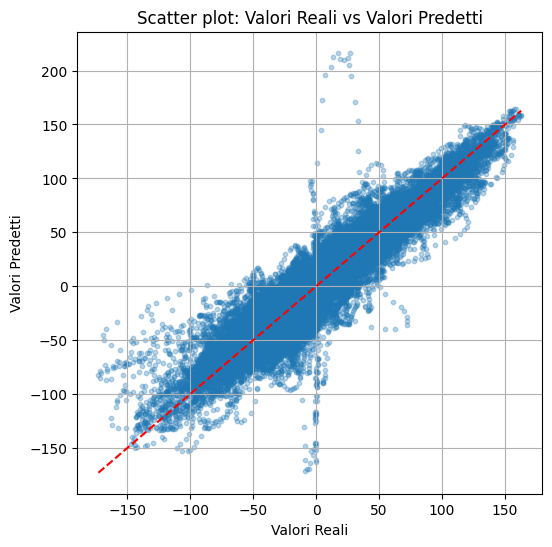

In [13]:
import matplotlib.pyplot as plt

# Prendi tutti i valori reali e predetti appiattiti (1D)
y_true = Y_val_flat.flatten()
y_pred = Y_pred.flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.3, s=10)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # retta y=x
plt.xlabel('Valori Reali')
plt.ylabel('Valori Predetti')
plt.title('Scatter plot: Valori Reali vs Valori Predetti')
plt.grid(True)
plt.show()


###MLP

In [14]:
import torch
import torch.nn as nn

#TODO: CONTROLLARE CHE SIA FATTO RISPETTANDO I CRITERI DI ANDY CHE AVEVA MOSTRATO NEL LAB 1 DI DLA
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, output_dim, time_steps, hidden_dims=[256, 128, 64]):
        """
        input_dim   : numero di feature per ogni step temporale (es. 5 sensori)
        output_dim  : numero di output per ogni step temporale (es. 3 assi accelerazione)
        time_steps  : lunghezza temporale della sequenza (es. 125)
        hidden_dims : lista con i neuroni per ogni hidden layer
        """
        super().__init__()
        self.input_dim = input_dim
        self.time_steps = time_steps
        self.output_dim = output_dim

        # Dimensione totale in input: time_steps * input_dim
        in_features = time_steps * input_dim
        out_features = time_steps * output_dim

        layers = []
        last_dim = in_features
        for h in hidden_dims:
            layers.append(nn.Linear(last_dim, h))
            layers.append(nn.ReLU())
            last_dim = h
        layers.append(nn.Linear(last_dim, out_features))

        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (batch_size, time_steps, input_dim)
        batch_size = x.shape[0]
        x = x.view(batch_size, -1)           # Flatten: (batch_size, time_steps * input_dim)
        out = self.mlp(x)                    # (batch_size, time_steps * output_dim)
        out = out.view(batch_size, self.time_steps, self.output_dim)
        return out



In [15]:
#assemblo i dataset
train_dat, val_dat = create_tensor_datasets(train, train_labels, val, val_labels)
#creo i dataloader
t_loader, v_loader = load_data(train_dat, val_dat, train_batch_size=64, test_batch_size=None, val_batch_size=64)
#istanzio il modello
mlp_regressor = MLPRegressor(5, 3, 125) #5 canali in input, 3 in output, 125 time steps per ognuno
#istanzio l'ottimizzatore
opt_for_mlp = torch.optim.Adam(mlp_regressor.parameters(), lr=1e-3)

#addestro il modello
model_mlp, _, history_mlp = train_pipeline(
    mlp_regressor,
    opt_for_mlp,
    loss_type="MSELoss",
    epochs=50,
    train_loader=t_loader,
    val_loader=v_loader,
    device=None,
    print_last_epoch_metrics=True,
    checkpoint_interval=0,
    checkpoint_dir=None,
    early_stopping=False,
    patience=None,
    scheduler=None
)

TypeError: 'int' object is not callable

In [ ]:
#plotto l'andamento di loss durante il training e durante la validation
plot_loss(history_mlp)

###Definizione del modello LSTM in PyTorch

In [ ]:
import torch
import torch.nn as nn
#input del modello (batch_size, sequence_length, input_dim). si specifica solo input_dim, il resto è determinato a runtime dal costruttore
class LSTMModel(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=100, output_dim=3, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)

        self.lstm2 = nn.LSTM(input_size=hidden_dim, hidden_size=hidden_dim, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)

        self.fc1 = nn.Linear(hidden_dim, 100)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(100, output_dim)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)
        out = self.dropout2(out)

        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out


###Addestramento del modello

In [ ]:
# Caricamento e normalizzazione dei dati
input_train = convert_mat_files_mean_std('Data_input_training_lin_comp.mat', 'I_train', 3000, 5, 125, 'normalization_stats/input_normalization.json').transpose((0,2,1))
output_train = convert_mat_files_mean_std('Data_output_training_lin_comp.mat', 'O_train', 3000, 3, 125, 'normalization_stats/output_normalization.json').transpose((0,2,1))
input_val = convert_mat_files_input_with_stats('Data_input_validation_lin_comp.mat', 'I_validation', 600, 5, 125, 'normalization_stats/input_normalization.json').transpose((0,2,1))
output_val = convert_mat_files_input_with_stats('Data_output_validation_lin_comp.mat', 'O_validation', 600, 3, 125, 'normalization_stats/output_normalization.json').transpose((0,2,1))

#assemblo i dataset
train_dataset, val_dataset = create_tensor_datasets(input_train, output_train, input_val, output_val)

#dataloaders
train_loader, val_loader = load_data(input_train, input_val, train_batch_size=64, test_batch_size=None, val_batch_size=64)


model = LSTMModel() #istanzio il modello

criterion = "MSELoss"
optimizer = optim.RMSprop(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=45, verbose=True)

model,_,history = train_pipeline(
    model,
    optimizer,
    loss_type=criterion,
    epochs=50,
    learning_rate=0.001,
    train_loader=train_loader,
    val_loader=val_loader,
    use_wandb=False,
    device=None,
    seed=42,
    reproducible=True,
    checkpoint_interval=0,
    checkpoint_dir=None,
    early_stopping=False,
    patience=None,
    dataset_name=None,
    project_name=None,
    scheduler=scheduler)

TypeError: 'int' object is not callable

In [ ]:
plot_loss(history)

###Caricamento del modello da un checkpoint

###Salvataggio e caricamento della cronologia dell'addestramento

In [ ]:
import pickle

# Salvataggio
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

# Caricamento
with open('training_history.pkl', 'rb') as f:
    loaded_history = pickle.load(f)


In [ ]:
#print(model)
#la parte di summary non è necessaria tanto qui facciamo solo esplorazione delle architetture, quindi non serve il summary e salvare come txt ecc.
#quello verrà fatto più avanti quando riporteremo il modello definitivo in keras.
#QUESTA VERSIONE PYTORCH E' EQUIVALENTE A QUELLA IN TENSORFLOW/KERAS FINO A QUI. LA PARTE DI COMPRESSIONE
#DEL MODELLO VERRA' EFFETTUATA CON TENSORFLOW/KERAS

## Convert model for deployment

A microprocessor has limited storage, memory, and computational power, so a direct deployment of a Keras model may be impractical. You’ll need to optimize and convert the model into a smaller, more efficient form.

Convert Keras Model to TensorFlow Lite (TFLite): TensorFlow Lite (TFLite) is optimized for mobile and embedded devices and can reduce the size and complexity of the model.

In [ ]:
# Create a fixed-batch model-
def get_model_fixed():
    model = keras.Sequential([
        keras.layers.Input(batch_shape=(1, sequence_length, 5)),  # fixes batch=1
        keras.layers.LSTM(100, return_sequences=True),
        keras.layers.LSTM(100, return_sequences=True),
        keras.layers.Dense(100, activation='relu'),
        keras.layers.Dense(3)
    ])
    return model

model_fixed = get_model_fixed()

# Build the model by passing a dummy input of shape (1, 250, 5)
model_fixed(np.zeros((1, sequence_length, 5), dtype=np.float32))

# Copy weights from the flexible model
model_fixed.set_weights(model.get_weights())

# Convert the fixed model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_fixed)
tflite_model = converter.convert()

# Save the model
tflite_path = "model_25ms_250points_normstd.tflite"

with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print(f"Saved TFLite model to {tflite_path}")

## Analyze model for deployment

Once the model has been converted into TensorFlow Lite (TFLite), the model can be analyzed using the *tf.lite.experimental.Analyzer.analyze* function. The list of all the operations of the model will be listed.

In [ ]:
tf.lite.experimental.Analyzer.analyze(model_path="model_25ms_250points_normstd.tflite")

## Quantized float16 model for deployment - optional

A microprocessor has limited storage, memory, and computational power, so a direct deployment of a Keras model may be impractical. You’ll need to optimize and convert the model into a smaller, more efficient form, and apply a quantization to reduce its dimensions. Here float16 quantization is used.

In [ ]:
# Load the model
loaded_model = keras.models.load_model('model_25ms_125points_normstd.keras')

In [ ]:
# e qui inizia a esplodere tutto
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_fp16_model = converter.convert()

In [ ]:
with open('model_25ms_250points_normstd_quantized.tflite','wb') as f:
    f.write(tflite_fp16_model)

## Test converted model for deployment

A microprocessor has limited storage, memory, and computational power, so a direct deployment of a Keras model may be impractical. You’ll need to optimize and convert the model into a smaller, more efficient form.

Test Converted Keras Model to TensorFlow Lite (TFLite): TensorFlow Lite (TFLite) is optimized for mobile and embedded devices and can reduce the size and complexity of the model.

Test the converted model 1 by 1 run

In [ ]:
sample_num = 3
sample = input_validation[sample_num:sample_num+1]  # shape (1,300,5)

keras_out = model_fixed.predict(sample)

interpreter = tf.lite.Interpreter('model_25ms_250points_normstd.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Feed the same sample into TFLite
interpreter.set_tensor(input_details[0]['index'], sample.astype(np.float32))
interpreter.invoke()
tflite_out = interpreter.get_tensor(output_details[0]['index'])

print("Keras output shape :", keras_out.shape)   # (1,250,3)
print("TFLite output shape:", tflite_out.shape)  # (1,250,3)


# Reshape to (300, 3) for easier plotting
keras_out = keras_out[0]
tflite_out = tflite_out[0]

# Plot each of the 3 output features
plt.figure(figsize=(12, 6))
for i in range(3):
    plt.plot(keras_out[:, i], label=f'Keras Output F{i}', linestyle='-')
    plt.plot(tflite_out[:, i], label=f'TFLite Output F{i}', linestyle='--')
    plt.plot(output_validation[sample_num, :, i], label=f'Expected F{i}', linestyle='--')

plt.title('Keras vs TFLite Output Comparison')
plt.xlabel('Timestep')
plt.ylabel('Output Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

All batches run together

In [ ]:
def plot_all_samples_keras_vs_tflite(input_data, model_fixed, tflite_path, output_data,samples_per_fig=5):
    """
    Run inference on all samples in input_data (shape: N x 250 x 5),
    compare Keras vs TFLite output, and plot each sample with all 3 features.
    """

    keras_outputs = []
    tflite_outputs = []

    print("Running inference on all samples...")
    for i in range(input_data.shape[0]):
        sample = input_data[i:i+1]  # shape (1, 300, 5)

         # --- TFLite Setup ---
        interpreter = tf.lite.Interpreter(model_path=tflite_path)
        interpreter.allocate_tensors()
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        # Keras inference
        keras_out = model_fixed.predict(sample, verbose=0)[0]  # shape (300, 3)

        # TFLite inference
        interpreter.set_tensor(input_details[0]['index'], sample.astype(np.float32))
        interpreter.invoke()
        tflite_out = interpreter.get_tensor(output_details[0]['index'])[0]  # shape (300, 3)

        keras_outputs.append(keras_out)
        tflite_outputs.append(tflite_out)

    keras_outputs = np.array(keras_outputs)      # shape (N, 250, 3)
    tflite_outputs = np.array(tflite_outputs)    # shape (N, 250, 3)

    # --- Plotting ---
    num_samples = input_data.shape[0]
    num_figs = int(np.ceil(num_samples / samples_per_fig))

    for fig_id in range(num_figs):
        fig, axs = plt.subplots(samples_per_fig, 1, figsize=(12, samples_per_fig * 2.5))
        axs = np.atleast_1d(axs)

        for i in range(samples_per_fig):
            sample_idx = fig_id * samples_per_fig + i
            if sample_idx >= num_samples:
                break

            ax = axs[i]
            for j in range(3):  # 3 output features
                ax.plot(output_data[sample_idx, :, j], label=f'Expected F{j}', linestyle='--')
                ax.plot(keras_outputs[sample_idx, :, j], label=f'Keras F{j}', linestyle='-')
                ax.plot(tflite_outputs[sample_idx, :, j], label=f'TFLite F{j}', linestyle='--')

            ax.set_title(f'Sample {sample_idx}')
            ax.set_xlabel('Timestep')
            ax.set_ylabel('Output')
            ax.legend(loc='upper right', ncol=3, fontsize='small')
            ax.grid(True)

        plt.tight_layout()
        plt.show()


In [ ]:
plot_all_samples_keras_vs_tflite(input_validation, model_fixed, tflite_path, output_validation, samples_per_fig=5)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_all_samples_keras_vs_tflite(
    input_data,
    model_fixed,
    tflite_path,
    samples_per_fig=5,
    output_dir="plots",
    show_plots=False
):
    """
    Run inference on all samples in input_data (shape: N x 250 x 5),
    compare Keras vs TFLite output, and plot each sample with all 3 features.
    Saves each figure in 'output_dir' e, opzionalmente, può mostrare le figure a schermo.
    """

    # Crea la cartella di destinazione se non esiste
    os.makedirs(output_dir, exist_ok=True)

    keras_outputs = []
    tflite_outputs = []

    print("Running inference on all samples...")
    for i in range(input_data.shape[0]):
        # Estrazione di un singolo sample: shape (1, 250, 5)
        sample = input_data[i:i+1]

        # --- TFLite Setup ---
        interpreter = tf.lite.Interpreter(model_path=tflite_path)
        interpreter.allocate_tensors()
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        # Keras inference
        keras_out = model_fixed.predict(sample, verbose=0)[0]  # shape (250, 3)

        # TFLite inference
        interpreter.set_tensor(input_details[0]['index'], sample.astype(np.float32))
        interpreter.invoke()
        tflite_out = interpreter.get_tensor(output_details[0]['index'])[0]  # shape (250, 3)

        keras_outputs.append(keras_out)
        tflite_outputs.append(tflite_out)

    keras_outputs = np.array(keras_outputs)    # shape (N, 250, 3)
    tflite_outputs = np.array(tflite_outputs)  # shape (N, 250, 3)

    # --- Plotting ---
    num_samples = input_data.shape[0]
    num_figs = int(np.ceil(num_samples / samples_per_fig))

    for fig_id in range(num_figs):
        fig, axs = plt.subplots(samples_per_fig, 1, figsize=(12, samples_per_fig * 2.5))
        axs = np.atleast_1d(axs)  # Garantisce che axs sia iterabile anche se c'è un solo subplot

        for i in range(samples_per_fig):
            sample_idx = fig_id * samples_per_fig + i
            if sample_idx >= num_samples:
                break

            ax = axs[i]
            for j in range(3):  # 3 output features
                ax.plot(keras_outputs[sample_idx, :, j], label=f'Keras F{j}', linestyle='-')
                ax.plot(tflite_outputs[sample_idx, :, j], label=f'TFLite F{j}', linestyle='--')

            ax.set_title(f'Sample {sample_idx}')
            ax.set_xlabel('Timestep')
            ax.set_ylabel('Output')
            ax.legend(loc='upper right', ncol=3, fontsize='small')
            ax.grid(True)

        plt.tight_layout()

        # Salvataggio dell'immagine
        fig_filename = f"plot_{fig_id}.png"
        save_path = os.path.join(output_dir, fig_filename)
        plt.savefig(save_path)
        print(f"Figure salvata: {save_path}")

        # Mostra il plot a schermo (opzionale, controllato da show_plots)
        if show_plots:
            plt.show()
        else:
            plt.close(fig)


In [ ]:
plot_all_samples_keras_vs_tflite(input_validation, model_fixed, tflite_path, samples_per_fig=5,output_dir="plots", show_plots=False)